In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("datasets/features_dataset.csv")

In [3]:
df.shape

(336749, 54)

In [4]:
df_corr = df.drop(columns=["URL","File_Extension","Suffix"])

In [14]:
df_corr["Label"] = df_corr["Label"].map({
    "Phishing":1,
    "Legitimate":0
})


In [15]:
corr_matrix = df_corr.corr()

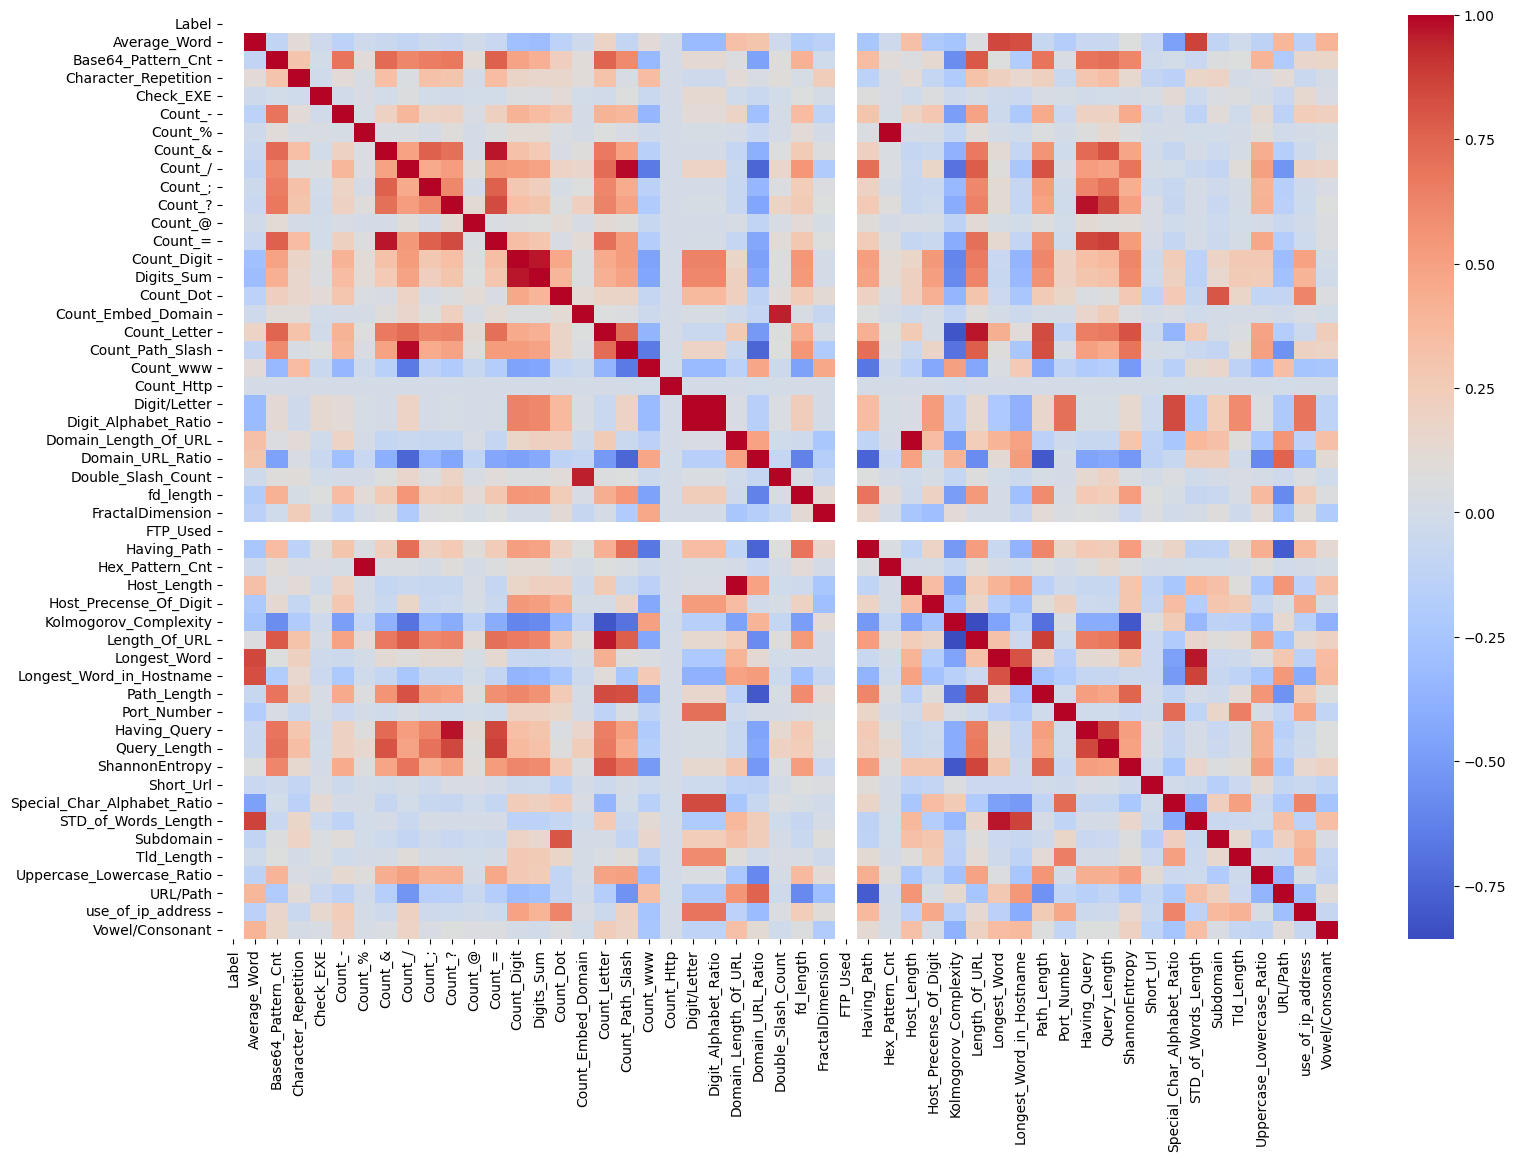

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

In [18]:
corr_matrix

,Label,Average_Word,Base64_Pattern_Cnt,Character_Repetition,Check_EXE,Count_-,Count_%,Count_&,Count_/,Count_;,...,ShannonEntropy,Short_Url,Special_Char_Alphabet_Ratio,STD_of_Words_Length,Subdomain,Tld_Length,Uppercase_Lowercase_Ratio,URL/Path,use_of_ip_address,Vowel/Consonant
Label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Average_Word,NaN,1.000000,0.109471,0.103632,0.027955,0.132201,0.027021,0.055699,0.092351,0.042159,...,0.065004,0.061129,0.476367,0.868279,0.106550,0.015933,0.130460,0.387902,0.144899,0.400786
Base64_Pattern_Cnt,NaN,0.109471,1.000000,0.307338,0.002049,0.692547,0.100103,0.730705,0.616582,0.657823,...,0.621910,0.029959,0.002091,0.066261,0.057658,0.066542,0.402054,0.201931,0.161644,0.166972
Character_Repetition,NaN,0.103632,0.307338,1.000000,0.017338,0.103086,0.033301,0.338718,0.043766,0.322426,...,0.137669,0.089880,0.143052,0.172881,0.192151,0.004521,0.040207,0.105019,0.053357,0.019665
Check_EXE,NaN,0.027955,0.002049,0.017338,1.000000,0.012969,0.040135,0.006996,0.063671,0.006050,...,0.004876,0.030612,0.124319,0.031975,0.044919,0.061018,0.020620,0.066240,0.138387,0.041839
Count_-,NaN,0.132201,0.692547,0.103086,0.012969,1.000000,0.024375,0.198501,0.386075,0.182705,...,0.444728,0.044145,0.009881,0.120849,0.099306,0.016202,0.131659,0.130241,0.244809,0.222928
Count_%,NaN,0.027021,0.100103,0.033301,0.040135,0.024375,1.000000,0.046538,0.049591,0.019616,...,0.057997,0.002502,0.013642,0.006284,0.007028,0.008430,0.081979,0.010140,0.001877,0.023862
Count_&,NaN,0.055699,0.730705,0.338718,0.006996,0.198501,0.046538,1.000000,0.497103,0.762589,...,0.481157,0.009551,0.076598,0.010859,0.030072,0.017218,0.440371,0.173070,0.027361,0.042733
Count_/,NaN,0.092351,0.616582,0.043766,0.063671,0.386075,0.049591,0.497103,1.000000,0.451080,...,0.694912,0.014186,0.002349,0.054392,0.093532,0.088412,0.502831,0.534396,0.202783,0.182215
Count_;,NaN,0.042159,0.657823,0.322426,0.006050,0.182705,0.019616,0.762589,0.451080,1.000000,...,0.432659,0.024215,0.072837,0.014281,0.024699,0.016304,0.409311,0.161566,0.024139,0.036479


In [17]:
import numpy as np

corr_matrix = df_corr.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_features = [column for column in upper.columns if any(upper[column] > 0.90)]

high_corr_features

['Count_=',
 'Digits_Sum',
 'Count_Path_Slash',
 'Digit_Alphabet_Ratio',
 'Double_Slash_Count',
 'Hex_Pattern_Cnt',
 'Host_Length',
 'Length_Of_URL',
 'Having_Query',
 'STD_of_Words_Length']

In [19]:
df_reduced = df_corr.drop(columns=high_corr_features)

In [20]:
df_reduced.shape

(336749, 41)